# 03 Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
def load(part):
    transaction = pd.read_csv(f"../data/raw/{part}_transaction.csv")
    identity = pd.read_csv(f"../data/raw/{part}_identity.csv")
    identity.columns = identity.columns.str.replace("-", "_")
    df = transaction.merge(identity, on="TransactionID", how="left")
    floats = df.select_dtypes("float64").columns
    df[floats] = df[floats].astype(np.float32)
    return df


df = pd.concat([load("train"), load("test")], ignore_index=True)
is_test = df["isFraud"].isna().to_numpy()
train_idx = np.flatnonzero(~is_test)
test_idx = np.flatnonzero(is_test)

print(df.shape, "train:", len(train_idx), "test:", len(test_idx))
print("sorted by time:", df["TransactionDT"].is_monotonic_increasing)

(1097231, 434) train: 590540 test: 506691
sorted by time: True


In [3]:
y = df.loc[train_idx, "isFraud"].astype(int).to_numpy()
dt = df["TransactionDT"].to_numpy()
day = dt // 86400

browser = df["id_31"].copy()
client = (df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_"
          + df["P_emaildomain"].astype(str)).to_numpy()

for col in df.select_dtypes(exclude="number").columns:
    codes = pd.factorize(df[col])[0]
    df[col] = np.where(codes == -1, np.nan, codes)

features = [c for c in df.columns if c not in ["TransactionID", "TransactionDT", "isFraud"]]
X = df[features + ["TransactionDT"]].astype(np.float32)
del df

print(len(features), "features")

431 features


## Train and test in time

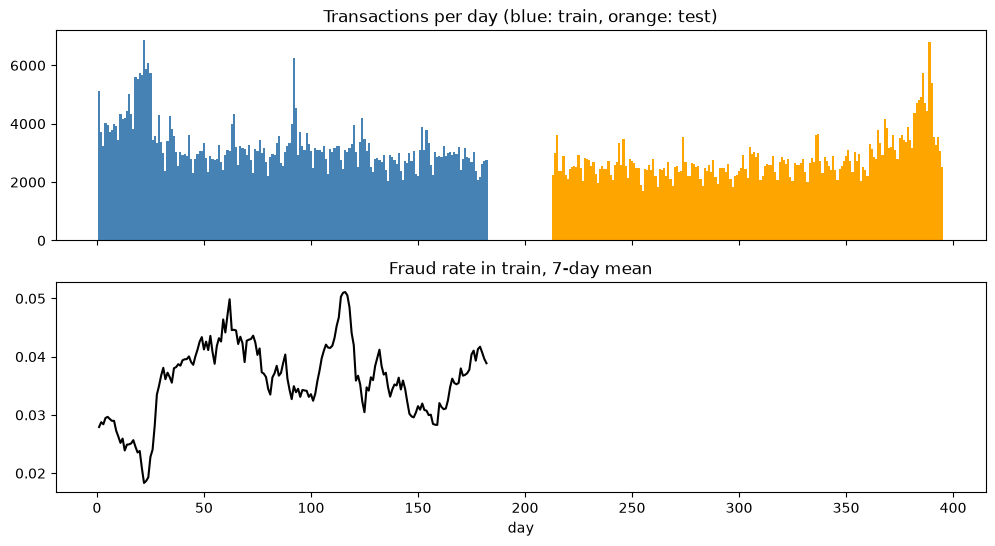

train days: 1 - 182
test days: 213 - 395


In [4]:
counts = pd.Series(is_test).groupby(day).agg(["size", "mean"])
daily_fraud = pd.Series(y).groupby(day[train_idx]).mean().rolling(7, center=True, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].bar(counts.index, counts["size"], color=np.where(counts["mean"] > 0, "orange", "steelblue"), width=1)
axes[0].set_title("Transactions per day (blue: train, orange: test)")
axes[1].plot(daily_fraud.index, daily_fraud.values, color="black")
axes[1].set_title("Fraud rate in train, 7-day mean")
axes[1].set_xlabel("day")
plt.show()

print("train days:", day[train_idx].min(), "-", day[train_idx].max())
print("test days:", day[test_idx].min(), "-", day[test_idx].max())

The test starts a month after train ends.

## Adversarial validation

In [5]:
rng = np.random.default_rng(42)
adv_train = np.sort(rng.choice(train_idx, size=120_000, replace=False))
adv_test = np.sort(rng.choice(test_idx, size=120_000, replace=False))
adv_idx = np.concatenate([adv_train, adv_test])
adv_y = np.r_[np.zeros(len(adv_train)), np.ones(len(adv_test))]

ADV_PARAMS = {
    "objective": "binary", "learning_rate": 0.1, "num_leaves": 31, "min_child_samples": 200,
    "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "max_bin": 63,
    "verbose": -1, "seed": 42,
}


def adversarial_auc(X_adv, cols):
    oof = np.zeros(len(adv_y))
    gain = np.zeros(len(cols))
    for tr, va in StratifiedKFold(3, shuffle=True, random_state=42).split(X_adv, adv_y):
        model = lgb.train(ADV_PARAMS, lgb.Dataset(X_adv[tr], adv_y[tr]), 150)
        oof[va] = model.predict(X_adv[va])
        gain += model.feature_importance("gain")
    importance = pd.Series(gain / gain.sum(), index=cols).sort_values(ascending=False)
    return roc_auc_score(adv_y, oof), oof, importance


X_adv = X.loc[adv_idx, features].to_numpy()
adv_auc, adv_oof, adv_imp = adversarial_auc(X_adv, features)

print("adversarial AUC:", round(adv_auc, 4))
print("gain share of top 10 features:", round(adv_imp.iloc[:10].sum(), 3))

adversarial AUC: 0.9091
gain share of top 10 features: 0.619


In [6]:
lr_rows = rng.choice(len(adv_idx), size=60_000, replace=False)

logreg = make_pipeline(
    SimpleImputer(strategy="median", keep_empty_features=True),
    StandardScaler(),
    LogisticRegression(C=0.1, max_iter=3000),
)
lr_oof = cross_val_predict(logreg, X_adv[lr_rows], adv_y[lr_rows], cv=3, method="predict_proba")[:, 1]

print("logistic regression:", round(roc_auc_score(adv_y[lr_rows], lr_oof), 4))
print("LightGBM:", round(adv_auc, 4))

logistic regression: 0.8001
LightGBM: 0.9091


AUC 0.91: the test is clearly different from train.

In [7]:
drift = pd.DataFrame({
    "gain share": adv_imp,
    "missing train": X.loc[adv_train, adv_imp.index].isna().mean(),
    "missing test": X.loc[adv_test, adv_imp.index].isna().mean(),
})
drift.head(20).round(3)

,gain share,missing train,missing test
id_31,0.220,0.763,0.731
D15,0.090,0.150,0.024
D10,0.075,0.129,0.025
id_13,0.066,0.785,0.743
V6,0.048,0.472,0.348
D4,0.032,0.287,0.152
D11,0.030,0.472,0.348
C12,0.021,0.000,0.000
dist1,0.020,0.596,0.574
V79,0.017,0.150,0.024


The most drifting features are the browser version, `D15`, `D10`, `D4` and columns that are missing less often in the test.

In [8]:
top_browsers = browser.iloc[test_idx].value_counts().index[:4].tolist() + browser.iloc[train_idx].value_counts().index[:2].tolist()

pd.DataFrame({
    "train": browser.iloc[train_idx].value_counts(normalize=True),
    "test": browser.iloc[test_idx].value_counts(normalize=True),
}).reindex(list(dict.fromkeys(top_browsers))).fillna(0).round(3)

,train,test
id_31,,
chrome 70.0,0.000,0.118
mobile safari 12.0,0.000,0.096
mobile safari 11.0,0.096,0.075
chrome 71.0,0.000,0.069
chrome 63.0,0.157,0.001


`chrome 63.0` is 16% of train and almost gone in the test, while newer versions don't exist in train.

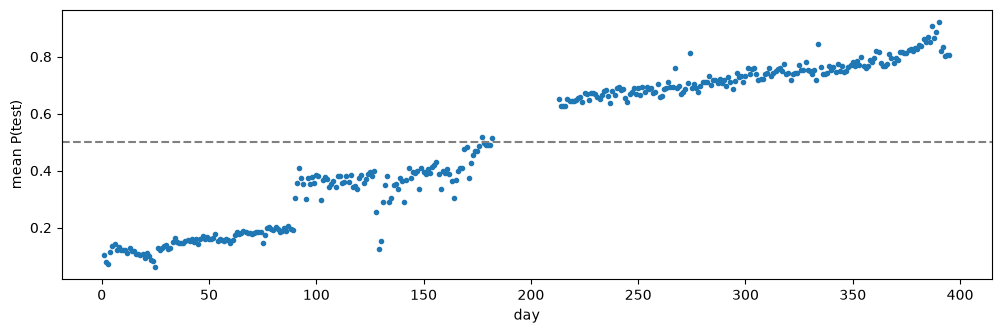

In [9]:
p_by_day = pd.Series(adv_oof).groupby(day[adv_idx]).mean()

plt.figure(figsize=(12, 3.5))
plt.plot(p_by_day.index, p_by_day.values, ".")
plt.axhline(0.5, color="gray", ls="--")
plt.xlabel("day")
plt.ylabel("mean P(test)")
plt.show()

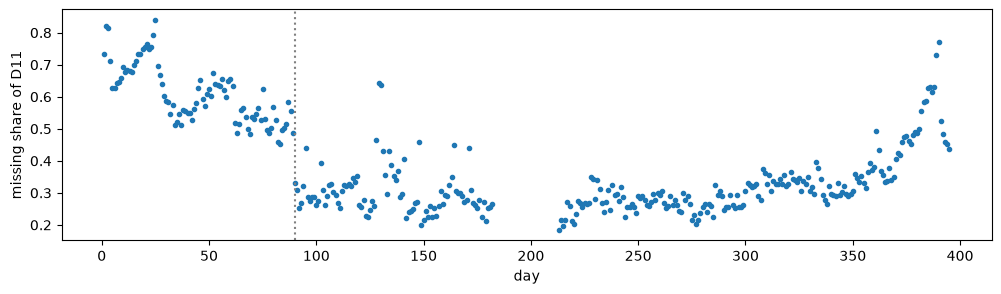

days 80-89: 0.514
days 90-99: 0.306
test: 0.348


In [10]:
d11_missing = X["D11"].isna().groupby(day).mean()

plt.figure(figsize=(12, 3))
plt.plot(d11_missing.index, d11_missing.values, ".")
plt.axvline(90, color="gray", ls=":")
plt.xlabel("day")
plt.ylabel("missing share of D11")
plt.show()

print("days 80-89:", round(d11_missing.loc[80:89].mean(), 3))
print("days 90-99:", round(d11_missing.loc[90:99].mean(), 3))
print("test:", round(X.loc[test_idx, "D11"].isna().mean(), 3))

The drift grows with time, with a jump around day 90.

In [11]:
for k in [0, 10, 20, 40, 80, 160]:
    keep = [c for c in features if c not in adv_imp.index[:k]]
    auc_k = adversarial_auc(X.loc[adv_idx, keep].to_numpy(), keep)[0]
    print(f"dropped {k:3d}: AUC {auc_k:.4f}")

dropped   0: AUC 0.9091


dropped  10: AUC 0.8262


dropped  20: AUC 0.8141


dropped  40: AUC 0.7913


dropped  80: AUC 0.7576


dropped 160: AUC 0.7282


Even after removing 160 features the AUC is still 0.73.

In [12]:
d_cols = [f"D{i}" for i in range(1, 16)]

X_norm = X_adv.copy()
for c in d_cols:
    j = features.index(c)
    X_norm[:, j] = day[adv_idx] - X_adv[:, j]

auc_norm, _, imp_norm = adversarial_auc(X_norm, features)

print("raw D:", round(adv_auc, 4))
print("day - D:", round(auc_norm, 4))
print(imp_norm.head())

raw D: 0.9091
day - D: 0.9999
D1     0.240618
D3     0.200642
D10    0.189694
D5     0.152486
D4     0.050208
dtype: float64


`day - D` makes the drift worse, but it is useful for a client id.

## Validation schemes

In [13]:
blocks4 = pd.qcut(dt[train_idx], 4, labels=False)
random_valid = rng.permutation(train_idx)[:len(train_idx) // 4]


def known_clients(train_rows, valid_rows):
    return np.isin(client[valid_rows], np.unique(client[train_rows])).mean()


def known_fraud_clients(train_rows, valid_rows):
    seen_fraud = np.unique(client[train_rows][y[train_rows] == 1])
    valid_fraud = valid_rows[y[valid_rows] == 1]
    return np.isin(client[valid_fraud], seen_fraud).mean()


last_block = train_idx[blocks4 == 3]
random_train = np.setdiff1d(train_idx, random_valid)

pd.DataFrame({
    "train -> test": {"valid rows with a known client": known_clients(train_idx, test_idx)},
    "time split (last quarter)": {
        "valid rows with a known client": known_clients(train_idx[blocks4 < 3], last_block),
        "valid fraud with a known fraud client": known_fraud_clients(train_idx[blocks4 < 3], last_block)},
    "random split": {
        "valid rows with a known client": known_clients(random_train, random_valid),
        "valid fraud with a known fraud client": known_fraud_clients(random_train, random_valid)},
}).round(3)

,train -> test,time split (last quarter),random split
valid rows with a known client,0.855,0.880,0.911
valid fraud with a known fraud client,NaN,0.634,0.850


With a random split 85% of the fraud in validation comes from already-seen fraud clients, with a time split only 63%.

In [14]:
blocks5 = pd.qcut(dt[train_idx], 5, labels=False)
cut = int(len(train_idx) * 0.8)

schemes = {
    "random 4-fold": list(StratifiedKFold(4, shuffle=True, random_state=42).split(train_idx, y)),
    "single time hold-out": [(np.arange(cut), np.arange(cut, len(train_idx)))],
    "forward chaining": [(np.flatnonzero(blocks5 <= k), np.flatnonzero(blocks5 == k + 1)) for k in [1, 2, 3]],
    "time-block 4-fold": [(np.flatnonzero(blocks4 != g), np.flatnonzero(blocks4 == g)) for g in range(4)],
}

In [15]:
top20 = adv_imp.index[:20]

PARAMS = {
    "objective": "binary", "learning_rate": 0.1, "num_leaves": 63, "min_child_samples": 100,
    "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "max_bin": 63,
    "verbose": -1, "seed": 42,
}

variants = {
    "all features": (features, {}),
    "+ TransactionDT": (features + ["TransactionDT"], {}),
    "no top-20 drift": ([c for c in features if c not in top20], {}),
    "deep trees": (features, {"num_leaves": 255, "min_child_samples": 20}),
    "shallow trees": (features, {"num_leaves": 7}),
}

In [16]:
results = []

for name, (cols, extra) in variants.items():
    params = {**PARAMS, **extra}
    X_train = X.loc[train_idx, cols].to_numpy()
    row = {"model": name}

    for scheme, folds in schemes.items():
        aucs = []
        for tr, va in folds:
            model = lgb.train(params, lgb.Dataset(X_train[tr], y[tr]), 150)
            aucs.append(roc_auc_score(y[va], model.predict(X_train[va])))
        row[scheme] = np.mean(aucs)
    results.append(row)
    print(name, "done")

grid = pd.DataFrame(results).set_index("model")
grid.round(4)

all features done


+ TransactionDT done


no top-20 drift done


deep trees done


shallow trees done


,random 4-fold,single time hold-out,forward chaining,time-block 4-fold
model,,,,
all features,0.9472,0.9139,0.9121,0.9151
+ TransactionDT,0.9495,0.9147,0.9122,0.9137
no top-20 drift,0.9443,0.9118,0.9105,0.9136
deep trees,0.9643,0.9169,0.9122,0.9178
shallow trees,0.8994,0.8837,0.8869,0.8847


Random 4-fold is about 0.03 too optimistic and flatters deep trees.

## Chosen strategy

Time-block 4-fold: it uses all of train and doesn't reward memorizing clients.